## Project : MatchMySkills — Semantic & Skill-Based Job Matching


### Group project : 

AMADOU Kassim <br>
AZEMAR Solene <br>
BELET Marine <br>
BENABDELJALIL Yanis

### Project Structure  

- competency_job.csv : The dataset containing all job and competency information

- functions.py : Contains all core utility functions for the project — including dataset loading and validation, text preprocessing, model loading, embeddings creation, and semantic evaluation logic.

- streamlit_app.py : The main interactive Streamlit application.
It provides the user interface where users describe their profile, projects, and skills, and then receive personalized job matching results with visualizations.

### Dataset

The dataset contains structured information about different jobs and their associated competencies. Each row represents a competency required for a specific job. It includes the following columns:
- JobID: Unique identifier for each job.
- JobTitle: The job title or role.
- CompetencyID: Unique identifier for each competency.
- CompetencyName: The name of the skill or competency.
- Weight: Importance of the competency for the job (scale from 1 to 5).
- Level: Proficiency level expected (e.g., Beginner, Intermediate, Advanced, Expert).
- Keywords: A list of relevant keywords associated with the competency, useful for semantic analysis and matching.

In total, the dataset contains 12 unique job roles (e.g., Data Analyst, Data Scientist, ML Engineer), dozens of competencies, and hundreds of job-competency mappings. This structure allows for detailed skill-level analysis, competency matching, and job recommendation based on both textual descriptions and user-input skill ratings.

### Introduction 

This notebook replicates the logic of the Streamlit app and the different functions in it.

**Sections:**
1. Data & model loading  
2. User input (profile, projects, skills)  
3. Semantic and questionnaire-based evaluation  
4. Results visualization

### Importing the libraries 

In [ ]:
# Core packages
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output
import plotly.express as px
from sentence_transformers import util

# Custom project functions
from functions import (
    load_and_validate_csv,
    build_competencies_unique,
    load_sbert_model,
    build_competency_embeddings,
    evaluate_user,
    clean_user_text,
    normalize_01,
    compute_question_scores
)

### 1. Load Data and Model

We define a cached function (for efficiency) to load the dataset, build unique competencies, load SBERT model, and compute embeddings. <br>
It includes the following steps and functions : 

- `load_and_validate_csv` to ensure the dataset is ready for analysis (column check, string cleaning and weight validation)
- `build_competencies_unique` to generate a unique list of competencies with clean text for embeddings
- `load_sbert_model`to load the pre-trained SBERT model used for semantic similarity
- `build_competency_embeddings` to build semantic embeddings for each unique competency using the SBERT model

In [ ]:
def load_all(csv_path="competency_job.csv", model_name="all-MiniLM-L6-v2"):
    df = load_and_validate_csv(csv_path)
    comp_unique = build_competencies_unique(df)
    model = load_sbert_model(model_name)
    comp_embs = build_competency_embeddings(comp_unique, model)
    return df, comp_unique, model, comp_embs

df, comp_unique, model, comp_embs = load_all()

display(Markdown("**Resources loaded successfully!**"))
display(Markdown(f"- {len(df)} job–competency pairs\n- {len(comp_unique)} unique competencies"))

df.head()

**Resources loaded successfully!**

- 109 job–competency pairs
- 37 unique competencies

,JobID,JobTitle,CompetencyID,CompetencyName,Weight,Level,Keywords
0,J01,Data Analyst,C01,Data Cleaning,4,Advanced,"data cleaning, data wrangling, preprocessing, ..."
1,J01,Data Analyst,C02,Data Visualization,5,Advanced,"data visualization, dashboards, charts, plots,..."
2,J01,Data Analyst,C03,SQL,5,Advanced,"SQL, queries, joins, subqueries, CTE, window f..."
3,J01,Data Analyst,C04,Exploratory Data Analysis,5,Advanced,"exploratory data analysis, EDA, descriptive st..."
4,J01,Data Analyst,C18,Business Intelligence,4,Advanced,"business intelligence, BI, reporting, dashboar..."


### 2. User Inputs (profile, projects, skills)  

#### Profile and Projects 

We created a section for the user to describe their profile in free text and another one to describe recent projects they worked on (Projects A and B)

These text inputs are crucial, as they will be tokenized and encoded by the Sentence-BERT model to generate the semantic vector used for comparison against the entire job competency database. Providing detailed, keyword-rich descriptions is essential for accurate semantic matching.

#### Skills

We created a section for the user to select their main skills and indicate their proficiency level. <br>
The user can select multiple skills loaded from all the unique competencies from the dataset and select a level (0 = beginner and 5 = expert)




### 3. Profile Evaluation

We created a button that triggers the evaluation of the user's profile, projects, and selected skills

It computes:

- Semantic similarity between the user's combined text and job competencies
- Skill-based (questionnaire) scores 
- Combined overall matching score (60 % Semantic and 40 % Skill)


### 4. Results Visualization
This shows:
- Top 5 matching jobs (based on the global score)
- Detailed scores (Semantic scores and Questionnaire skill scores)
- Top 10 Competency Matches (based on the Semantic score)


### Methodology and Planning 

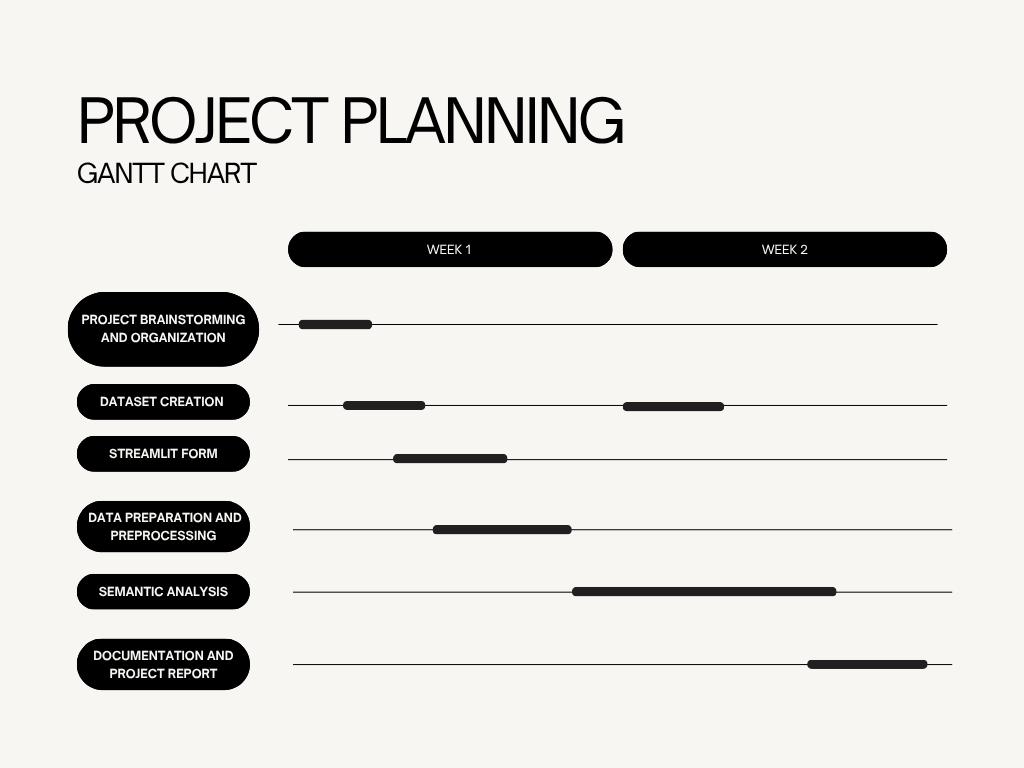

# Time for the demonstration !